In [3]:
import numpy as np
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import os.path as op
from  nilearn.datasets import fetch_surf_fsaverage
from os import listdir
import seaborn as sns   
import pandas as pd
fsaverage = fetch_surf_fsaverage()

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
grad_folder = 'derivatives/gradients'
plot_folder_name = '/Users/mrenke/data/ds-stressrisk/plots_and_ims/gradients123_reordMaskFlip'
subList = [f[4:6] for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==6]

specification = '_reordMaskFlip'



In [3]:
gradInsp_subList = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/gradient_inspection_list.csv')

cleanGM_subList = gradInsp_subList[gradInsp_subList['Order'] == '1']['Subject'].to_list()
cleanGM_subList = [int(x) for x in cleanGM_subList]
cleanGM_subList = ["{:02d}".format(x) for x in cleanGM_subList]

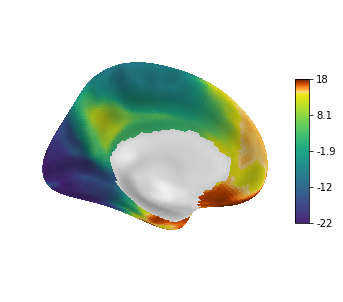

In [8]:
import nilearn.plotting as npl
from utils_02 import get_GMmargulies_cmap 

cmap = get_GMmargulies_cmap() # 'viridis' # 
view =  'medial' #'dorsal'#'ventral' #
grad_n = 2
hemi = 'L'
surf_mesh  = fsaverage.infl_right if hemi == 'R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi == 'R' else fsaverage.sulc_left
gm = -nib.load(op.join(bids_folder,grad_folder,'sub-average_cmunfil_01','ses-1',f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-{hemi}_grad{grad_n}_noParcel.surf.gii')).agg_data()

nplt.plot_surf(surf_mesh= surf_mesh, surf_map= gm, # infl_right # pial_right
               view= view,cmap=cmap, colorbar=True,
               bg_map=bg_map, bg_on_data=True,darkness=0.5,
               )
plt.show()

# r2 & GM <3

In [5]:
# get average r2 maps

fsaverage = fetch_surf_fsaverage(mesh='fsaverage')

def get_r2_data_from_surf(sub,bids_folder ='/Volumes/mrenkeED/data/ds-stressrisk',hemi='R', 
                          space='fsaverage', key='encoding_model.denoise.retroicor.smoothed'):
    pati =  op.join(bids_folder, f'derivatives/{key}/sub-{sub}/ses-1/func/') 
    file =  op.join(pati, f'sub-{sub}_ses-1_desc-r2.optim.nilearn_space-{space}_hemi-{hemi}.func.gii')
    return nib.load(file).agg_data()

In [7]:
subList_ = subList
N_vertcices = 327684 # len(r2_data_l) + len(r2_data_r)
r2_all = np.zeros((len(subList_), N_vertcices))
                  
for sub in subList_:
    r2_data_l= get_r2_data_from_surf(sub,hemi='L')
    r2_data_r= get_r2_data_from_surf(sub,hemi='R')
    r2_sub= np.concatenate((r2_data_l,r2_data_r))
    r2_all[subList_.index(sub),:] = r2_sub
    
r2_av = np.mean(r2_all,axis=0)
r2_av_allSubs_l, r2_av_allSubs_r = np.split(r2_av,2)

In [ ]:
import seaborn as sns   

r2_av_r_ = r2_av_allSubs_r
#r2_av_r_[r2_av_r_<0.04] = np.nan

cmap = 'viridis'
figure, axes = plt.subplots(nrows=1, ncols=3, figsize=(14,5),subplot_kw=dict(projection='3d'))
nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= r2_av_r_, # infl_right # pial_right
               view= 'medial',cmap=cmap, colorbar=False, title=f'r2 average', axes=axes[0],
               bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.5)
nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= r2_av_r_, # infl_right # pial_right
               view= 'posterior',cmap=cmap, colorbar=False, title=f'r2 average', axes=axes[1],  
               bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.5)
nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= r2_av_r_, # infl_right # pial_right
               view= 'dorsal',cmap=cmap, colorbar=True, title=f'r2 average', axes=axes[2],
               bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.5)
plt.show()

plt.fig()
sns.kdeplot(r2_av_r,shade=True)

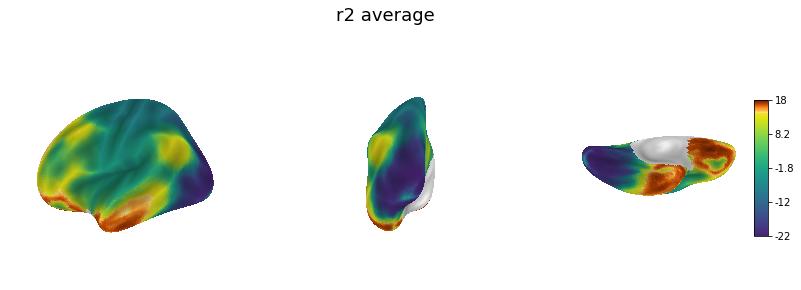

In [9]:
hemi = 'L'
grad_n = 2
gm = -nib.load(op.join(bids_folder,grad_folder,'sub-average_cmunfil_01','ses-1',f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage_hemi-{hemi}_grad{grad_n}_noParcel.surf.gii')).agg_data()
gm_r2 = gm

r2_av_half = r2_av_allSubs_l if hemi == 'L' else r2_av_allSubs_r
#gm_r2[r2_av_half>0.04] = np.nan

cmap = get_GMmargulies_cmap() # 'viridis' # 
surf_mesh  = fsaverage.infl_right if hemi == 'R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi == 'R' else fsaverage.sulc_left
side_view = 'medial' if hemi == 'R' else 'lateral'

figure, axes = plt.subplots(nrows=1, ncols=3, figsize=(14,5),subplot_kw=dict(projection='3d'))
nplt.plot_surf(surf_mesh= surf_mesh, surf_map= gm_r2, # infl_right # pial_right
               view= side_view,cmap=cmap, colorbar=False, title=f'r2 average', axes=axes[0],
               bg_map=bg_map, bg_on_data=True,darkness=0.5)
nplt.plot_surf(surf_mesh= surf_mesh, surf_map= gm_r2, # infl_right # pial_right
               view= 'posterior',cmap=cmap, colorbar=False, title=f'r2 average', axes=axes[1],  
               bg_map=bg_map, bg_on_data=True,darkness=0.5)
nplt.plot_surf(surf_mesh= surf_mesh, surf_map= gm_r2, # infl_right # pial_right
               view= 'ventral',cmap=cmap, colorbar=True, title=f'r2 average', axes=axes[2],
               bg_map=bg_map, bg_on_data=True,darkness=0.5)
plt.show()

In [ ]:
from utils import fsav5Tofsav

fsav5Tofsav(sub='average_cmunfil_01',ses=1,specification='_noParcel',bids_folder=bids_folder)

## morphospace plots

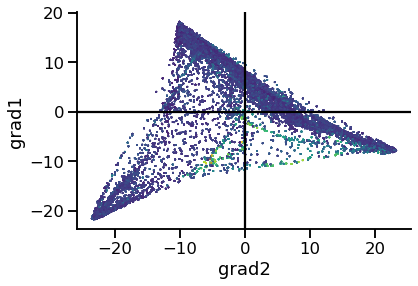

In [203]:
hemi = 'L'
gm1 = -nib.load(op.join(bids_folder,grad_folder,'sub-average_cmunfil_01','ses-1',f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage_hemi-{hemi}_grad2_noParcel.surf.gii')).agg_data()
gm2 = -nib.load(op.join(bids_folder,grad_folder,'sub-average_cmunfil_01','ses-1',f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage_hemi-{hemi}_grad1_noParcel.surf.gii')).agg_data()

r2_av_half = r2_av_l if hemi == 'L' else r2_av_r
plt.scatter(gm2,gm1, s=0.1, c = r2_av_r, cmap =cmap) 
#plt.scatter(gm2,gm1, s=0.1, c = gm1, cmap =cmap) tp check that visual regions lie in lower left corner and DMN-regions at top
plt.axvline(x=0, color = 'black')
plt.axhline(y=0, color = 'black')
plt.xlabel('grad2')
plt.ylabel('grad1')
sns.despine()

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/seaborn/axisgrid.py:2182: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


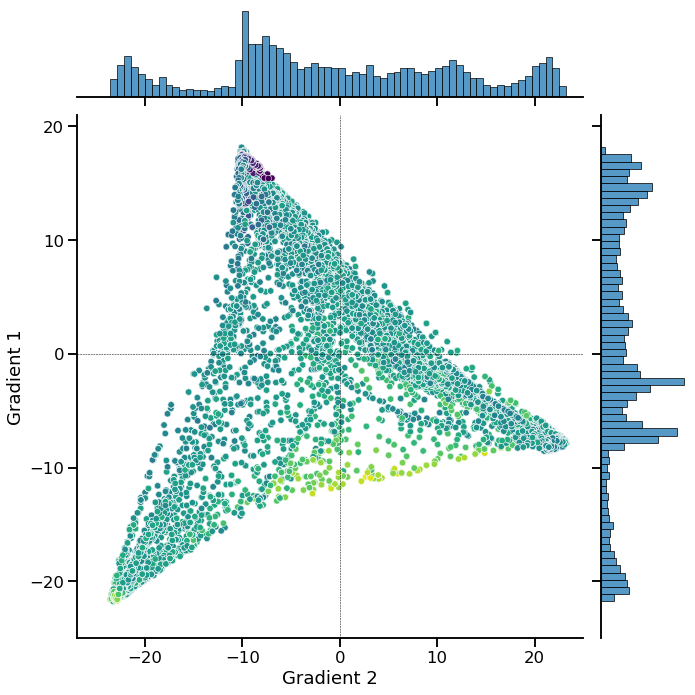

In [205]:
import pandas as pd

df =pd.DataFrame(data=list(zip(gm1,gm2,r2_av_half)),columns = ['grad 1','grad 2','r2'])

sns.set_context("talk")
g = (sns.jointplot(y='grad 1', x='grad 2',
                   data=df, 
                   size=10, label='big', linewidth=0, marker='.',  alpha=0.8,legend=False,
                   ylim =[-25, 21],#[np.min(df['e0']) - 0.5, np.max(df['e0']) + 0.5], 
                   xlim=[-27, 25] #[np.min(df['e1']) - 0.5, np.max(df['e1']) + 0.5],
                   ).set_axis_labels('Gradient 2', 'Gradient 1'))

sns.scatterplot(y='grad 1', x='grad 2', hue='r2', data=df, ax=g.ax_joint,palette='viridis',size=10,legend=False)
g.ax_joint.axvline(x=0, color = 'black', linestyle='--', linewidth=0.5)
g.ax_joint.axhline(y=0, color = 'black', linestyle='--', linewidth=0.5)


--> gradient loadings not normally distributed, but r2 is (half-normally/skewed)

sns.kdeplot(r2_av_r,shade=True)

### ind. subject morphoplots

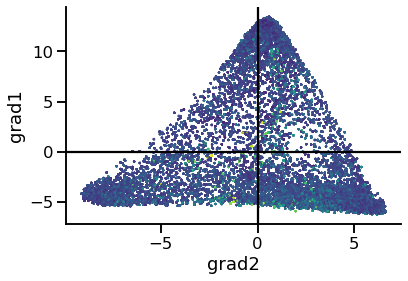

In [206]:
#from utils_02 import get_GMmargulies_cmap   
plot_folder_name = '/Users/mrenke/data/ds-stressrisk/plots_and_ims/r2_grad-morphospace'

sub = '59'
hemi='L'
specification = '_reordMaskFlip'
cmap = get_GMmargulies_cmap(skewed=True) # 'viridis' #

space = 'fsaverage'
r2_av_r = get_r2_data_from_surf(sub,hemi=hemi,space=space)

#r2_av_r[r2_av_r>0.1] =+ 0.1
#fsav5Tofsav(sub=sub,ses=1,specification=specification,bids_folder=bids_folder)
gm1 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad1{specification}.surf.gii')).agg_data()
gm2 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad2{specification}.surf.gii')).agg_data()

plt.scatter(gm2,gm1, s=0.5, c = r2_av_r, cmap =cmap)
plt.axvline(x=0, color = 'black')
plt.axhline(y=0, color = 'black')
plt.xlabel('grad2')
plt.ylabel('grad1')
sns.despine()

In [ ]:
# loop for such a  plot for each subject

import os
from utils import fsav5Tofsav

plot_folder_name = '/Users/mrenke/data/ds-stressrisk/plots_and_ims/r2_grad-morphospace'

hemi='R'
specification = '_reordMaskFlip'
cmap = get_GMmargulies_cmap(skewed=False) # 'viridis' #
space = 'fsaverage'

for sub in subList:
    r2_av_r = get_r2_data_from_surf(sub,hemi=hemi,space=space)

    gm_file = op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad1{specification}.surf.gii')
    if (os.path.exists(gm_file) == False):
        fsav5Tofsav(sub=sub,ses=1,specification=specification,bids_folder=bids_folder)
        
    gm1 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad1{specification}.surf.gii')).agg_data()
    gm2 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad2{specification}.surf.gii')).agg_data()

    plt.scatter(gm2,gm1, s=0.5, c = r2_av_r, cmap =cmap)
    plt.axvline(x=0, color = 'black')
    plt.axhline(y=0, color = 'black')
    plt.xlabel('grad2')
    plt.ylabel('grad1')
    sns.despine()
    plt.savefig(op.join(plot_folder_name,f'sub-{sub}_space-{space}_hemi-{hemi}.png'))
    plt.close()

## Gradient bins
bin based on grad values (wihtin each sub), get r2 val of that bin and create new morphoplot....

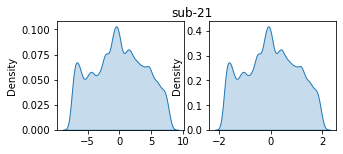

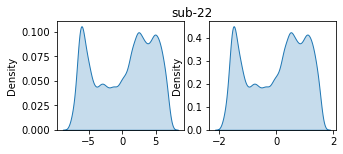

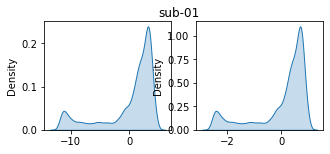

In [43]:
import scipy.stats as stats 

for sub in subList[:3]:
    #vertex_values = get_r2_data_from_surf(sub,hemi=hemi,space=space)
    vertex_values = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad1{specification}.surf.gii')).agg_data()
    vertex_values = vertex_values[~np.isnan(vertex_values)] # gradient maps contain NaNs

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5,2))
    sns.kdeplot(vertex_values,shade=True, ax=axes[0])
    sns.kdeplot(stats.zscore(vertex_values),shade=True, ax=axes[1])
    fig.suptitle(f'sub-{sub}')


--> it preserves the shape and the position of the mean, which is 0 also for the non z-scored gradient

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='grad2_bin', ylabel='grad1_bin'>

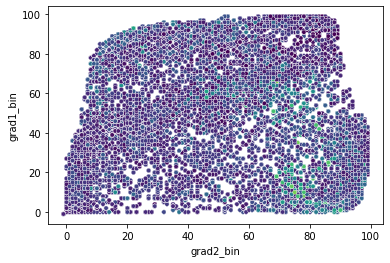

In [168]:
sub=32 # 59
hemi='R'
space = 'fsaverage'
specification = '_reordMaskFlip'

r2_av_r = get_r2_data_from_surf(sub,hemi=hemi,space=space)  
gm1 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad1{specification}.surf.gii')).agg_data()
gm2 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad2{specification}.surf.gii')).agg_data()

df =pd.DataFrame(data=list(zip(gm1,gm2,r2_av_r)),columns = ['grad1','grad2','r2'])

df['grad1_bin'] = pd.qcut(df['grad1'],100,labels=range(100)).cat.codes
df['grad2_bin'] = pd.qcut(df['grad2'],100,labels=range(100)).cat.codes

sns.scatterplot(df['grad2_bin'],df['grad1_bin'],hue=df['r2'],palette='viridis',size=0.1,legend=False)

In [249]:
from matplotlib import colors

cmap = colors.LinearSegmentedColormap.from_list(
    'Custom cmap', plt.cm.viridis(np.linspace(0, 1, 256)), 256)
cmap.set_bad(color='gray')

Text(0.5, 1.0, 'subject GM based bins - mean r2 - hemi-L')

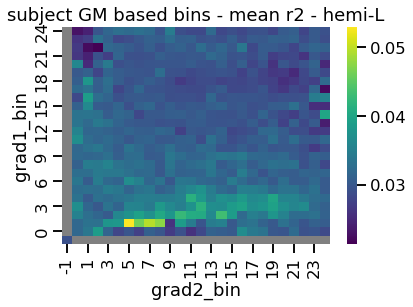

In [250]:
n_bins = 25
hemi = 'L'
subList_ = cleanGM_subList

df_all = pd.DataFrame()
for sub in subList_:
    r2_av_r = get_r2_data_from_surf(sub,hemi=hemi,space=space)  
    gm1 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad1{specification}.surf.gii')).agg_data()
    gm2 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad2{specification}.surf.gii')).agg_data()

    df =pd.DataFrame(data=list(zip(gm1,gm2,r2_av_r)),columns = ['grad1','grad2','r2'])

    new_df = pd.DataFrame()
    new_df['grad1_bin'] = pd.qcut(df['grad1'],n_bins,labels=range(n_bins)).cat.codes
    new_df['grad2_bin'] = pd.qcut(df['grad2'],n_bins,labels=range(n_bins)).cat.codes
    new_df[f'r2_sub{sub}'] = df['r2']

    new_df.set_index(['grad1_bin','grad2_bin'],inplace=True)
    new_df = new_df.groupby(['grad1_bin','grad2_bin']).mean()
    df_all = pd.concat([df_all,new_df],axis=1)
    #df_all.join(new_df)

#df_all.head()
hm = df_all.mean(axis=1).unstack('grad2_bin').loc[::-1]
#sns.heatmap(hm)
ax = sns.heatmap(hm, cmap=cmap)
ax.set_title(f'subject GM based bins - mean r2 - hemi-{hemi}')


Text(0.5, 1.0, 'Average GM based bins - mean r2 - hemi-R')

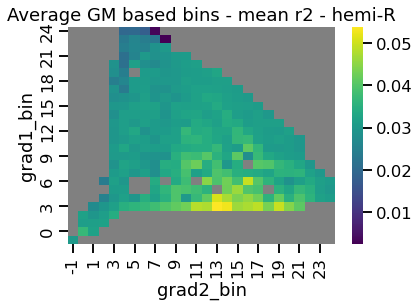

In [216]:
# same with average grad values
hemi = 'R'
gm1 = -nib.load(op.join(bids_folder,grad_folder,'sub-average_cmunfil_01','ses-1',f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage_hemi-{hemi}_grad2_noParcel.surf.gii')).agg_data()
gm2 = -nib.load(op.join(bids_folder,grad_folder,'sub-average_cmunfil_01','ses-1',f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage_hemi-{hemi}_grad1_noParcel.surf.gii')).agg_data()

n_bins = 25
df_all = pd.DataFrame()

for sub in subList[1:]:
    r2_av_r = get_r2_data_from_surf(sub,hemi=hemi,space=space)  
    df =pd.DataFrame(data=list(zip(gm1,gm2,r2_av_r)),columns = ['grad1','grad2','r2'])

    new_df = pd.DataFrame()
    new_df['grad1_bin'] = pd.qcut(df['grad1'],n_bins,labels=range(n_bins)).cat.codes
    new_df['grad2_bin'] = pd.qcut(df['grad2'],n_bins,labels=range(n_bins)).cat.codes
    new_df[f'r2_sub{sub}'] = df['r2']

    new_df.set_index(['grad1_bin','grad2_bin'],inplace=True)
    new_df = new_df.groupby(['grad1_bin','grad2_bin']).mean()
    df_all = pd.concat([df_all,new_df],axis=1)
    #df_all.join(new_df)

#df_all.head()
hm = df_all.mean(axis=1).unstack('grad2_bin').loc[::-1]
ax = sns.heatmap(hm, cmap=cmap)
ax.set_title(f'Average GM based bins - mean r2 - hemi-{hemi}')



### Regression model r2 ~ grad1*grad2 .....

In [7]:
# first get datafram in numrefield env
hemi='R'
mask = True
space = 'fsaverage'
specification = '_reordMaskFlip'
mask_fsaverageR = nib.load('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/surface_masks/desc-NPC_R_space-fsaverage_hemi-rh.label.gii').agg_data()
mask_fsaverageR = [bool(x) for x in mask_fsaverageR]

subList_ = cleanGM_subList
df_comb = pd.DataFrame()
for sub in subList_:
    r2_av_r = get_r2_data_from_surf(sub,hemi=hemi,space=space)  
    gm1 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad1{specification}.surf.gii')).agg_data()
    gm2 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad2{specification}.surf.gii')).agg_data()

    df =pd.DataFrame(data=list(zip(gm1,gm2,r2_av_r,r2_av_allSubs_r)),columns = ['grad1','grad2','r2','av_r2'])
    df['subject'] = int(sub)
    df['vertex_n'] = df.index.values

    if mask:       
        df = df[mask_fsaverageR]
    df_comb = pd.concat([df_comb,df],axis=0)

df_comb.to_csv(f'/Users/mrenke/data/ds-stressrisk/interim_sum_data/grad1-grad2-r2_avr2_space-{space}_NPCmask-{mask}.csv')
# vertex_n respected by r2_av_allSubs_r order ?!


In [2]:
# change to behav_fit environment, actually behav-fit2_clone, behav_fit complained about datatype of a column that was just a normal float...
import bambi
import pandas as pd
import numpy as np
import os.path as op

space = 'fsaverage'
mask = True
df_comb = pd.read_csv(f'/Users/mrenke/data/ds-stressrisk/interim_sum_data/grad1-grad2-r2_avr2_space-{space}_NPCmask-{mask}.csv')
print(df_comb.shape)
df_comb = df_comb.dropna(subset=['av_r2', 'r2','grad1', 'grad2', 'subject'])
print(df_comb.shape)

(410754, 7)
(410754, 7)


In [ ]:
# fit model
formula_1 = 'r2 ~ av_r2 + grad1*grad2 + (grad1*grad2|subject)'
formula_2 = 'r2 ~ av_r2 + grad1*{grad2**2} + (grad1*{grad2**2}|subject)' # Use {grad2**2} or I(grad2**2) to compute the math power./ Exponentiation on an individual variable returns the variable as it is.
formula_2 = 'r2 ~ av_r2 + grad1*grad2*{grad2**2} + subject' 


model = bambi.Model(formula_2, data=df_comb)
idata = model.fit()

path_model = '/Users/mrenke/data/ds-stressrisk/interim_sum_data/'
idata.to_netcdf(op.join(path_model,f'regres_r2-avr2-grad1-grad2exp_space-{space}_NPCmask-{mask}.netcdf'))

# for formula_2 it took 1117m

In [ ]:
import arviz as az  

traces = az.from_netcdf(op.join(path_model,f'regres_r2-avr2-grad1-grad2exp_space-{space}_NPCmask-{mask}.netcdf'))
regressors = list(traces.posterior.data_vars)

for reg in regressors:
    post = idata.posterior[reg].to_dataframe()
    plt.figure(figsize=(2.5,2.5))
    sns.kdeplot(post,fill=True)
    plt.axvline(x=0, color = 'black')  

##
- think about manually aligning outlier subjects , or have a file...

* make the same with grad values from gm_average
* overlay scatterplots
* do it with hemi-L

* generate average gradient from averaging over subject wise gradients!

ahh, I might actually have the conn. file from the HCP:
/Volumes/mrenkeED/data/connectivity_stuff/HCP_S1200_812_rfMRI_MSMAll_groupPCA_d4500ROW_zcorr_recon2.dconn.nii